In [1]:
import numpy as np
import pandas as pd
import matplotlib.pylab as plt
import ot
import cvxpy as cp
import seaborn as sns
import twp_utils as twp

# Supplementary Packages
#import scipy.stats as stats
#import scipy.special as sps
#import time as t

## Medicare Data

In [68]:
def read_medicaid(file_name, columns, sample = True):
    
    df = pd.read_csv(file_name)[columns]
    
    if sample:
        df = df.sample(1500, random_state = 1)
    
    return(np.array(df))

In [69]:
import os, glob
medidata = []

columns1 = ['HINSCAID','EMPSTAT','UHRSWORK','INCWAGE']
for file in sorted(glob.glob("../workingData/pre_intervention/*.csv")):
    medidata.append(read_medicaid(file, columns1))

medidata.insert(0, medidata.pop(5)) # Move Montana to front of list
medi_target = medidata[0]
medi_controls = medidata[1:]


#for counterfactual exercise
mt_years = read_medicaid("../workingData/pre_intervention/MT.csv", ['YEAR'])

### Test Run

In [70]:
medi_weights, medi_projection = twp.tan_wass_proj(medi_target, medi_controls)

# round integer columns
medi_projection[:,0:2] = medi_projection[:,0:2].round(decimals = 0).astype('int32')

In [71]:
medi_target[0:5,:]

array([[ 1.        ,  1.        ,  4.63666885, 11.11364122],
       [ 1.        ,  1.        ,  2.99573227,  9.92818017],
       [ 1.        ,  1.        ,  4.3795235 , 10.16334869],
       [ 1.        ,  1.        ,  4.23120374, 10.70817611],
       [ 2.        ,  2.        ,  1.22377543,  4.21950771]])

In [72]:
medi_projection[0:5,:]

array([[ 1.        ,  1.        ,  4.54818717, 11.06689179],
       [ 1.        ,  1.        ,  3.02134537,  9.98865912],
       [ 1.        ,  1.        ,  4.31903949, 10.24728821],
       [ 1.        ,  1.        ,  4.19650691, 10.75115837],
       [ 1.        ,  2.        ,  1.30804684,  5.14307799]])

In [107]:
np.round(medi_weights, 3)
medi_weights = np.array([0.056, 0.   , 0.   , 0.051, 0.251, 0.   , 0.078, 0.33 , 0.043,
       0.008, 0.11 , 0.073])

## RESULTS

### HINSCAID

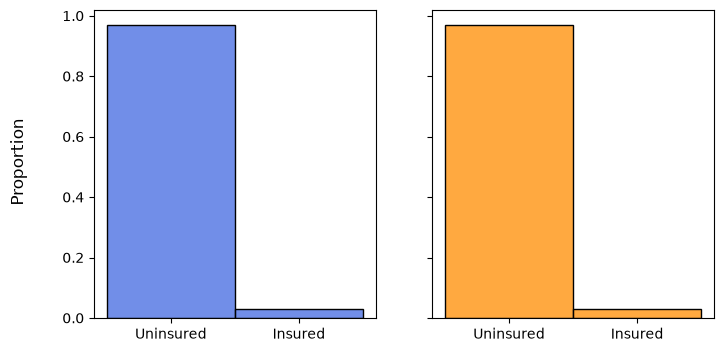

In [108]:
fig5, axes5 = plt.subplots(1,2, figsize = (8,4), sharex = True, sharey = True)

dict_map = {1:'Uninsured' , 2: 'Insured'}
reptemp = pd.DataFrame(medi_projection[:,0])
reptemp[0] = reptemp[0].map(dict_map)

targtemp = pd.DataFrame(medi_target[:,0])
targtemp[0] = targtemp[0].map(dict_map)

sns.histplot(reptemp, x = 0, ax = axes5[0], discrete = True, stat = 'density', color = 'royalblue')
sns.histplot(targtemp, x = 0, ax = axes5[1], discrete = True, stat = 'density', color = 'darkorange')
axes5[0].set(xlabel = None, ylabel = None)
axes5[1].set(xlabel = None, ylabel = None)
fig5.supylabel('Proportion')

plt.savefig('hinscaid_pre.png')

In [109]:
1500 - sum(medi_target[:,0] == medi_projection[:,0]) ## number of misses

np.int64(2)

### EMPSTAT

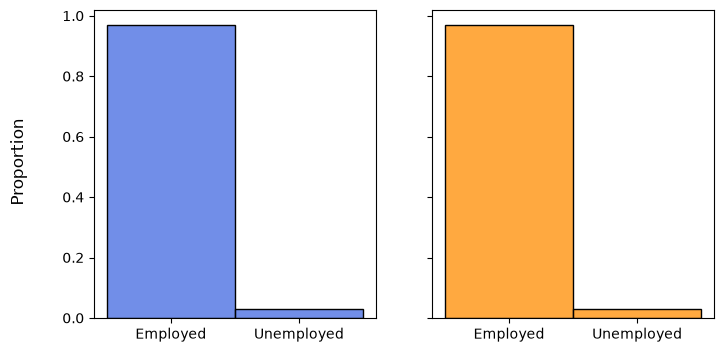

In [110]:
fig6, axes6 = plt.subplots(1,2, figsize = (8,4), sharex = True, sharey = True)

dict_map = {1:'Employed' , 2: 'Unemployed'}
reptemp = pd.DataFrame(medi_projection[:,0])
reptemp[0] = reptemp[0].map(dict_map)

targtemp = pd.DataFrame(medi_target[:,0])
targtemp[0] = targtemp[0].map(dict_map)

sns.histplot(reptemp, x = 0, ax = axes6[0], discrete = True, stat = 'density', color = 'royalblue')
sns.histplot(targtemp, x = 0, ax = axes6[1], discrete = True, stat = 'density', color = 'darkorange')
axes6[0].set(xlabel = None, ylabel = None)
axes6[1].set(xlabel = None, ylabel = None)
fig6.supylabel('Proportion')

plt.savefig('empstat_pre.png')

In [111]:
1500 - sum(medi_target[:,1] == medi_projection[:,1]) ## number of misses

np.int64(2)

### UHRSWORK

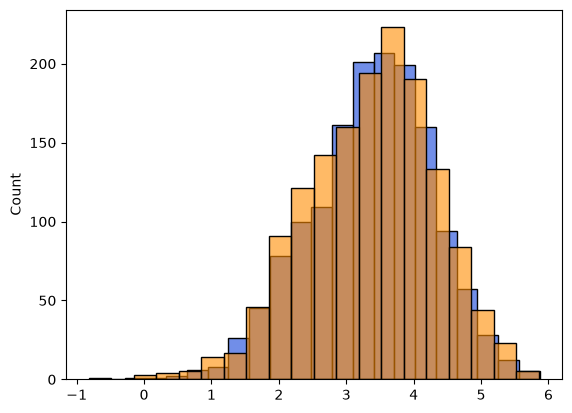

In [112]:
fig7, axes7 = plt.subplots()
sns.histplot(medi_projection[:,2], ax = axes7, bins = 20, color = 'royalblue')
sns.histplot(medi_target[:,2], ax = axes7, bins = 20, color = 'darkorange', alpha = 0.6)

plt.savefig('uhrswrk_pre.png')

### INCWAGE

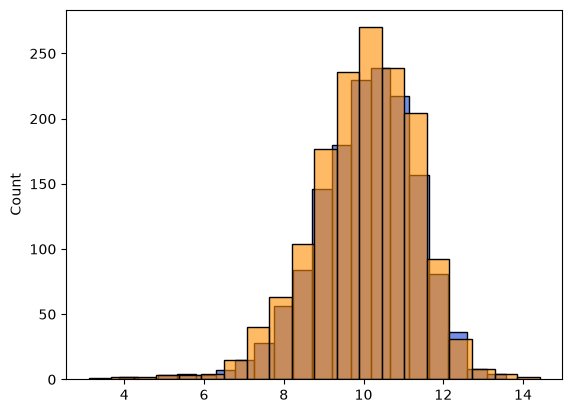

In [113]:
fig8, axes8 = plt.subplots()
sns.histplot(medi_projection[:,3], ax = axes8, bins = 20, color = 'royalblue')
sns.histplot(medi_target[:,3], ax = axes8, bins = 20, color = 'darkorange', alpha = 0.6)

plt.savefig('incwage_pre.png')

## Counterfactual Data

In [114]:
def read_medicaid2(file_name, columns, sample = True):
    
    df = pd.read_csv(file_name)[columns]
    
    if sample:
        df = df.sample(7775, random_state = 31) #7775 is minimum data size
    
    return(np.array(df)) 

In [115]:
postintv = []
import glob

# check path
for file in sorted(glob.glob("../workingData/post_intervention/*.csv")):
    postintv.append(read_medicaid2(file, columns1))

postintv.insert(0, postintv.pop(5))
post_target = postintv[0]
post_controls = postintv[1:]

mt_years = read_medicaid2("../workingData/post_intervention/MT_post.csv", ['YEAR'])

In [116]:
pd.DataFrame(post_target).describe()

,0,1,2,3
count,7775.000000,7775.000000,7775.000000,7775.000000
mean,1.084373,1.018135,3.353679,10.166747
std,0.277964,0.133448,0.953723,1.309781
min,1.000000,1.000000,-1.897120,2.533697
25%,1.000000,1.000000,2.740840,9.369095
50%,1.000000,1.000000,3.440418,10.281581
75%,1.000000,1.000000,4.018183,11.050890
max,2.000000,2.000000,6.731972,14.461084


In [117]:
pd.DataFrame(medi_target).describe()

,0,1,2,3
count,1500.000000,1500.000000,1500.000000,1500.000000
mean,1.030667,1.021333,3.355350,10.004246
std,0.172470,0.144541,0.957379,1.323336
min,1.000000,1.000000,-0.820981,3.109061
25%,1.000000,1.000000,2.699513,9.190138
50%,1.000000,1.000000,3.451572,10.083093
75%,1.000000,1.000000,4.023474,10.919952
max,2.000000,2.000000,5.858219,14.415868


In [118]:
post_projection = sum([a*b for a,b in zip(medi_weights, post_controls)])
post_projection[:,0:2] = post_projection[:,0:2].round(decimals = 0).astype('int32')

### HINSCAID

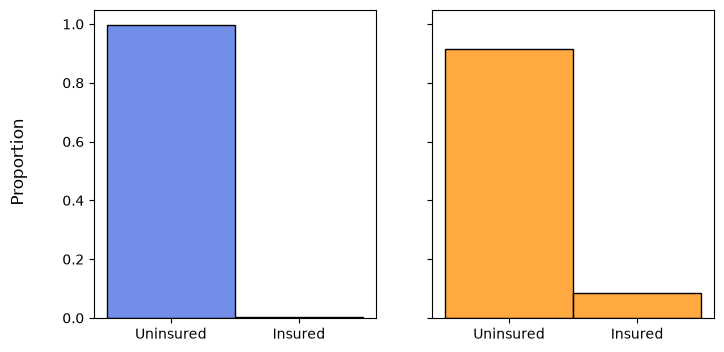

In [119]:
fig, axes = plt.subplots(1,2, figsize = (8,4), sharex = True, sharey = True)

dict_map = {1:'Uninsured' , 2: 'Insured'}
reptemp = pd.DataFrame(post_projection[:,0])
reptemp[0] = reptemp[0].map(dict_map)

targtemp = pd.DataFrame(post_target[:,0])
targtemp[0] = targtemp[0].map(dict_map)

sns.histplot(reptemp, x = 0, ax = axes[0], discrete = True, stat = 'density', color = 'royalblue')
sns.histplot(targtemp, x = 0, ax = axes[1], discrete = True, stat = 'density', color = 'darkorange')
axes[0].set(xlabel = None, ylabel = None)
axes[1].set(xlabel = None, ylabel = None)

fig.supylabel('Proportion')
plt.savefig('hinscaid_sep.png')

### EMPSTAT

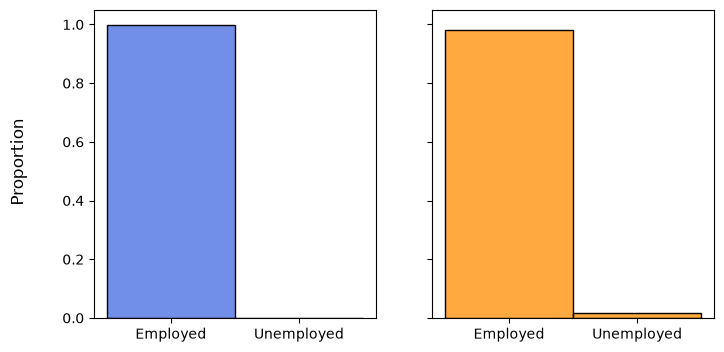

In [120]:
fig2, axes2 = plt.subplots(1,2, figsize = (8,4), sharex = True, sharey = True)

dict_map = {1:'Employed' , 2: 'Unemployed'}
reptemp = pd.DataFrame(post_projection[:,1])
reptemp[0] = reptemp[0].map(dict_map)

targtemp = pd.DataFrame(post_target[:,1])
targtemp[0] = targtemp[0].map(dict_map)

sns.histplot(reptemp, x = 0, ax = axes2[0], discrete = True, stat = 'density', color = 'royalblue')
sns.histplot(targtemp, x = 0, ax = axes2[1], discrete = True, stat = 'density', color = 'darkorange')
axes2[0].set(xlabel = None, ylabel = None)
axes2[1].set(xlabel = None, ylabel = None)

fig2.supylabel('Proportion')

plt.savefig('empstat_sep.png')

### UHRSWORK

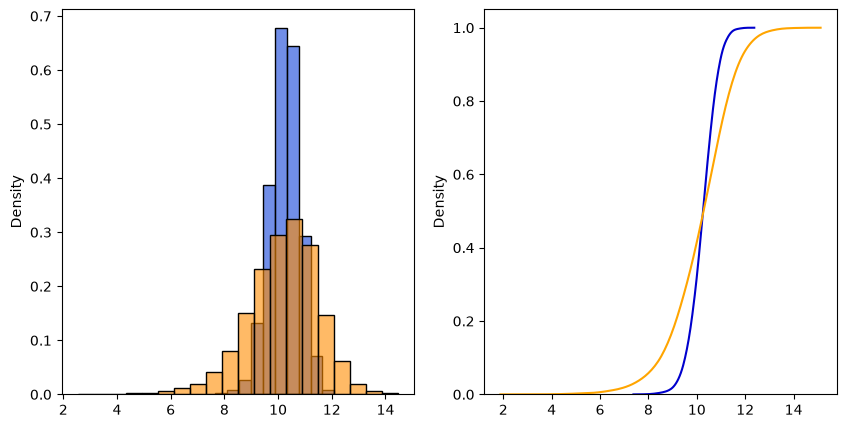

In [121]:
fig3, axes3 = plt.subplots(1,2, figsize = (10,5))
sns.histplot(post_projection[:,3], bins = 10, ax = axes3[0], color = 'royalblue', stat = 'density')
sns.kdeplot(post_projection[:,3], cumulative = True, ax = axes3[1], color = 'mediumblue')


sns.histplot(post_target[:,3], bins = 20, ax = axes3[0], color = 'darkorange', stat = 'density', alpha = 0.6)
sns.kdeplot(post_target[:,3], cumulative = True, ax = axes3[1], color = 'orange')

plt.savefig('incwage_superimposed.png')

### INCWAGE

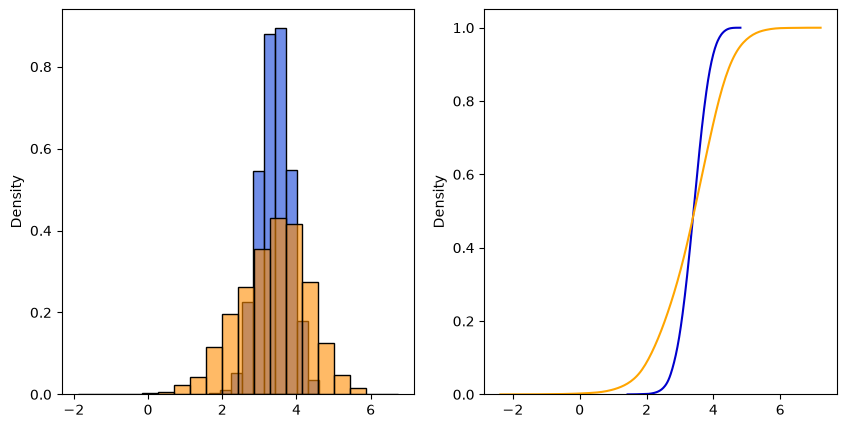

In [122]:
fig4, axes4 = plt.subplots(1,2, figsize = (10,5))
sns.histplot(post_projection[:,2], bins = 10, ax = axes4[0], color = 'royalblue', stat = 'density')
sns.kdeplot(post_projection[:,2], cumulative = True, ax = axes4[1], color = 'mediumblue')


sns.histplot(post_target[:,2], bins = 20, ax = axes4[0], color = 'darkorange', stat = 'density', alpha = 0.6)
sns.kdeplot(post_target[:,2], cumulative = True, ax = axes4[1], color = 'orange')

plt.savefig('uhrswork_superimposed.png')